# Generación de GIFs desde PNGs de simulación

Genera tres GIFs por cada combinación `N{X}_crestas / positivo|negativo`:
- `Gif_mapa/mapa_corrientes.gif`
- `GIF_cooper/densidad_cooper.gif`
- `Gif_Vi/curva_VI.gif`

In [1]:
# Instalar Pillow si no está disponible
import importlib
if importlib.util.find_spec("PIL") is None:
    import subprocess
    subprocess.run(["pip", "install", "Pillow"], check=True)
print("Pillow listo ✓")

Pillow listo ✓


In [2]:
import re
from pathlib import Path
from PIL import Image

In [3]:
# ─────────────────────────────────────────────
# CONFIGURACIÓN  ← ajusta solo esta celda
# ─────────────────────────────────────────────

# Ruta raíz donde está N50_crestas (solo esta carpeta se procesará)
ROOT = Path(".")   # cambia si es necesario

N_VALUES   = [50]
POLARITIES = ["positivo", "negativo"]

# Carpeta → (prefijo de los png, nombre del gif de salida)
GIF_MAP = {
    "Gif_mapa"   : ("mapa_corrientes",  "mapa_corrientes.gif"),
    "GIF_cooper" : ("densidad_cooper",  "densidad_cooper.gif"),
    "Gif_Vi"     : ("curva_VI",         "curva_VI.gif"),
}

# Duración de cada frame en milisegundos
FRAME_DURATION_MS = 300

# True  → el gif se repite indefinidamente
# False → se reproduce una sola vez
LOOP = True

In [4]:
def extraer_indice(path: Path) -> int:
    """Extrae el número entre paréntesis del nombre, p.ej. mapa_corrientes_(3).png → 3."""
    match = re.search(r"\((\d+)\)", path.stem)
    return int(match.group(1)) if match else 0


def hacer_gif(png_folder: Path, prefix: str, gif_name: str,
              duration: int, loop: bool) -> bool:
    """Lee los PNGs ordenados y guarda el GIF en la misma carpeta."""
    frames_paths = sorted(
        [p for p in png_folder.glob(f"{prefix}_(*).png")],
        key=extraer_indice
    )

    if not frames_paths:
        print(f"  [AVISO] Sin frames en {png_folder}")
        return False

    frames = [Image.open(p).convert("RGBA") for p in frames_paths]

    # Convertir a paleta para GIF (modo P)
    frames_p = []
    for f in frames:
        bg = Image.new("RGB", f.size, (255, 255, 255))
        bg.paste(f, mask=f.split()[3])   # aplica canal alpha
        frames_p.append(bg)

    gif_path = png_folder / gif_name
    frames_p[0].save(
        gif_path,
        save_all=True,
        append_images=frames_p[1:],
        duration=duration,
        loop=0 if loop else 1,
        optimize=False
    )
    print(f"  ✓ {gif_path}  ({len(frames_p)} frames)")
    return True


def generar_todos(root, n_values, polarities, gif_map, duration, loop):
    total = 0
    for n in n_values:
        for polarity in polarities:
            base = root / f"N{n}_crestas" / polarity
            if not base.exists():
                print(f"[AVISO] No existe: {base}")
                continue

            print(f"\n{'='*55}")
            print(f"  N{n}_crestas / {polarity}")
            print(f"{'='*55}")

            for folder_name, (prefix, gif_name) in gif_map.items():
                folder = base / folder_name
                if not folder.exists():
                    print(f"  [AVISO] No existe: {folder}")
                    continue
                ok = hacer_gif(folder, prefix, gif_name, duration, loop)
                if ok:
                    total += 1

    print(f"\n✅ Proceso terminado — {total} GIFs generados.")


generar_todos(ROOT, N_VALUES, POLARITIES, GIF_MAP, FRAME_DURATION_MS, LOOP)


  N50_crestas / positivo
  ✓ N50_crestas/positivo/Gif_mapa/mapa_corrientes.gif  (13 frames)
  ✓ N50_crestas/positivo/GIF_cooper/densidad_cooper.gif  (13 frames)
  ✓ N50_crestas/positivo/Gif_Vi/curva_VI.gif  (13 frames)

  N50_crestas / negativo
  ✓ N50_crestas/negativo/Gif_mapa/mapa_corrientes.gif  (13 frames)
  ✓ N50_crestas/negativo/GIF_cooper/densidad_cooper.gif  (13 frames)
  ✓ N50_crestas/negativo/Gif_Vi/curva_VI.gif  (13 frames)

✅ Proceso terminado — 6 GIFs generados.


## Vista previa rápida

Corre la siguiente celda para previsualizar un GIF directamente en el notebook.

Mostrando: N50_crestas/positivo/Gif_mapa/mapa_corrientes.gif


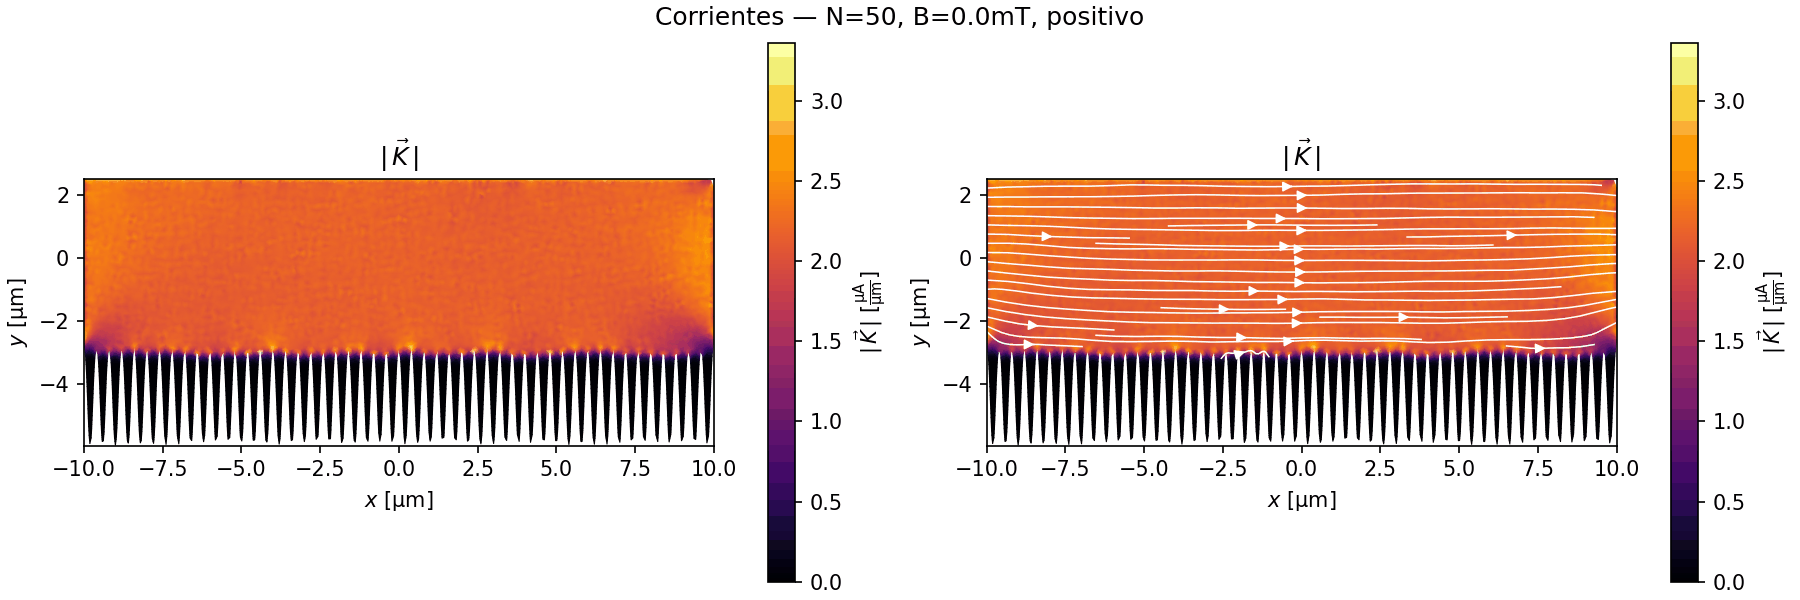

In [5]:
from IPython.display import Image as IPImage, display

# ── Cambia estos valores para ver el GIF que quieras ──
PREVIEW_N        = 50
PREVIEW_POLARITY = "positivo"
PREVIEW_FOLDER   = "Gif_mapa"         # Gif_mapa | GIF_cooper | Gif_Vi
PREVIEW_GIF      = "mapa_corrientes.gif"
# ─────────────────────────────────────────────────────

gif_preview = ROOT / f"N{PREVIEW_N}_crestas" / PREVIEW_POLARITY / PREVIEW_FOLDER / PREVIEW_GIF

if gif_preview.exists():
    print(f"Mostrando: {gif_preview}")
    display(IPImage(filename=str(gif_preview)))
else:
    print(f"No encontrado: {gif_preview}")